# THỰC HÀNH 03: PHÁT HIỆN ĐỐI TƯỢNG (OBJECT DETECTION) VỚI YOLOv8

## Thông tin chung

Bài thực hành thuộc môn **Thị Giác Máy Tính Nâng Cao** (*Advanced Computer Vision - K35 - HCMUS*).

- Thành viên nhóm:
  - Nguyễn Trọng Hiếu – 25C11042 (Nhóm trưởng)
  - Trương Lê Bảo Trân – 25C11071
- Giảng viên hướng dẫn: ThS. Nguyễn Mạnh Hùng

---

## Mục tiêu notebook

Notebook này dùng để **suy luận (inference) mô hình YOLOv8 phát hiện mũ bảo hiểm** từ checkpoint đã huấn luyện.  
Quy trình không sử dụng Google Drive mounting, thay vào đó checkpoint và ảnh/zip đầu vào được tải trực tiếp bằng link.

Luồng thực hiện:

1. Cài đặt thư viện cần thiết.
2. Tải checkpoint `best.pt` và ảnh hoặc file `.zip` đầu vào bằng link.
3. Nạp mô hình YOLOv8 đã huấn luyện.
4. Chạy inference trên ảnh kiểm thử.
5. Hiển thị ảnh dự đoán, xuất bảng Bounding Box và nén kết quả.


### 1. Kiểm tra môi trường

Mục tiêu của bước này là kiểm tra phiên bản Python, PyTorch và khả năng sử dụng GPU. Nếu chạy trên Google Colab, nên chọn Runtime có GPU để tăng tốc suy luận.


In [1]:
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Đang chạy bằng CPU. Notebook vẫn chạy được nhưng tốc độ sẽ chậm hơn.")


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cpu
CUDA available: False
Đang chạy bằng CPU. Notebook vẫn chạy được nhưng tốc độ sẽ chậm hơn.


### 2. Cài đặt thư viện

Các thư viện chính gồm `ultralytics` để nạp YOLOv8, `gdown` để tải file từ Google Drive link mà không cần mount Drive, cùng các thư viện xử lý ảnh và bảng kết quả.


In [2]:
# Cài đặt thư viện cần thiết cho YOLOv8 inference.
!pip install -q ultralytics gdown opencv-python pandas pillow matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.1 MB/s eta 0:00:00


### 3. Import thư viện và cấu hình thư mục

Toàn bộ dữ liệu tạm, checkpoint, ảnh đầu vào và kết quả dự đoán được lưu trong `/content/yolov8_helmet_inference`. Có thể tải file kết quả ở cuối notebook.


In [3]:
from pathlib import Path
import os
import sys
import shutil
import subprocess
import urllib.request
import zipfile
from typing import List

import pandas as pd
from PIL import Image as PILImage
from IPython.display import Image, display
from ultralytics import YOLO

WORK_DIR = Path("/content/yolov8_helmet_inference")
CHECKPOINT_DIR = WORK_DIR / "checkpoints"
INPUT_DIR = WORK_DIR / "inputs"
IMAGE_DIR = INPUT_DIR / "images"
ZIP_DIR = INPUT_DIR / "zip"
EXTRACT_DIR = INPUT_DIR / "extracted"
OUTPUT_DIR = WORK_DIR / "outputs"

for folder in [CHECKPOINT_DIR, IMAGE_DIR, ZIP_DIR, EXTRACT_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Working directory:", WORK_DIR)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Working directory: /content/yolov8_helmet_inference


### 4. Cấu hình link checkpoint và dữ liệu inference

Có hai cách cung cấp dữ liệu đầu vào:

- **Cách 1:** Gán link ảnh vào `IMAGE_URLS`.
- **Cách 2:** Gán link file `.zip` vào `ZIP_URL`; file zip có thể chứa nhiều ảnh, thư mục `labels/` hoặc file `.csv` tham chiếu.

Nếu dùng Google Drive, đặt link ở dạng share công khai hoặc dạng `https://drive.google.com/uc?id=FILE_ID`. Notebook chỉ tải file bằng link, không mount Drive.


In [4]:
# Checkpoint YOLOv8 đã huấn luyện từ notebook train.
# Thay link này bằng link checkpoint best.pt của nhóm nếu cần.
CHECKPOINT_URL = "https://drive.google.com/uc?id=1CIpbnz5pJhk8aW3gVYedneF7r_aiQdi6"

# Cách 1: danh sách ảnh kiểm thử tải bằng link.
# Có thể thêm nhiều link ảnh vào danh sách này.
IMAGE_URLS = [
    "https://drive.google.com/uc?id=183TnIBGfq8JNRqoWzsHyMA7UYXmSEnIL",
]

# Cách 2: link file zip chứa ảnh kiểm thử.
# Nếu không dùng zip thì để chuỗi rỗng.
ZIP_URL = ""

CHECKPOINT_PATH = CHECKPOINT_DIR / "best_helmet_yolov8.pt"
INPUT_ZIP_PATH = ZIP_DIR / "input_images.zip"


### 5. Tải checkpoint và ảnh đầu vào

Hàm `download_file` hỗ trợ cả Google Drive link và direct URL. Sau khi tải, notebook tự kiểm tra kích thước file để tránh lỗi file rỗng.


In [5]:
def download_file(url: str, output_path: Path) -> Path:
    '''Tải file từ Google Drive link hoặc direct URL.'''
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if not url:
        raise ValueError("URL đang rỗng.")

    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"Đã tồn tại: {output_path}")
        return output_path

    print(f"Đang tải: {url}")
    print(f"Lưu tại: {output_path}")

    if "drive.google.com" in url:
        subprocess.run(
            [sys.executable, "-m", "gdown", "--fuzzy", url, "-O", str(output_path)],
            check=True,
        )
    else:
        urllib.request.urlretrieve(url, output_path)

    if not output_path.exists() or output_path.stat().st_size == 0:
        raise FileNotFoundError(f"Tải thất bại hoặc file rỗng: {output_path}")

    print(f"Hoàn tất: {output_path} | {output_path.stat().st_size / 1024:.2f} KB")
    return output_path


def collect_images(root: Path) -> List[Path]:
    '''Thu thập tất cả ảnh trong một thư mục.'''
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted([p for p in Path(root).rglob("*") if p.suffix.lower() in exts])


def copy_images_to_input_dir(image_paths: List[Path]) -> List[Path]:
    '''Chuẩn hóa ảnh về IMAGE_DIR để YOLOv8 chạy batch inference.'''
    copied = []
    for idx, src in enumerate(image_paths, start=1):
        src = Path(src)
        dst = IMAGE_DIR / src.name
        if dst.exists():
            dst = IMAGE_DIR / f"image_{idx:03d}{src.suffix.lower()}"
        shutil.copy2(src, dst)
        copied.append(dst)
    return copied

# 1. Tải checkpoint.
checkpoint_path = download_file(CHECKPOINT_URL, CHECKPOINT_PATH)

# 2. Tải ảnh hoặc zip dữ liệu đầu vào.
if ZIP_URL:
    zip_path = download_file(ZIP_URL, INPUT_ZIP_PATH)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    extracted_images = collect_images(EXTRACT_DIR)
    image_paths = copy_images_to_input_dir(extracted_images)
else:
    image_paths = []
    for idx, url in enumerate(IMAGE_URLS, start=1):
        suffix = ".jpg"
        image_path = IMAGE_DIR / f"helmet_test_{idx:03d}{suffix}"
        image_paths.append(download_file(url, image_path))

# 3. Nếu không có link, thử dùng ảnh mẫu trong src/assets nếu notebook được đặt trong project.
if len(image_paths) == 0:
    local_candidates = []
    for local_dir in [Path("src/assets"), Path("/content/src/assets")]:
        if local_dir.exists():
            local_candidates.extend(collect_images(local_dir))
    image_paths = copy_images_to_input_dir(local_candidates)

if len(image_paths) == 0:
    raise FileNotFoundError("Không tìm thấy ảnh đầu vào. Hãy cấu hình IMAGE_URLS hoặc ZIP_URL.")

print(f"Số ảnh đầu vào: {len(image_paths)}")
for p in image_paths[:10]:
    print("-", p)


Đang tải: https://drive.google.com/uc?id=1CIpbnz5pJhk8aW3gVYedneF7r_aiQdi6
Lưu tại: /content/yolov8_helmet_inference/checkpoints/best_helmet_yolov8.pt
Hoàn tất: /content/yolov8_helmet_inference/checkpoints/best_helmet_yolov8.pt | 21995.35 KB
Đang tải: https://drive.google.com/uc?id=183TnIBGfq8JNRqoWzsHyMA7UYXmSEnIL
Lưu tại: /content/yolov8_helmet_inference/inputs/images/helmet_test_001.jpg
Hoàn tất: /content/yolov8_helmet_inference/inputs/images/helmet_test_001.jpg | 27.76 KB
Số ảnh đầu vào: 1
- /content/yolov8_helmet_inference/inputs/images/helmet_test_001.jpg


### 6. Kiểm tra dữ liệu tham chiếu nếu có

Nếu file `.zip` có chứa nhãn YOLO (`.txt`) hoặc file `.csv`, notebook sẽ liệt kê để người đọc biết dữ liệu tham chiếu đang có trong gói đầu vào. Bước này không bắt buộc cho inference.


In [6]:
reference_files = []
if EXTRACT_DIR.exists():
    reference_files.extend(EXTRACT_DIR.rglob("*.csv"))
    reference_files.extend(EXTRACT_DIR.rglob("*.txt"))

reference_files = sorted(reference_files)

if reference_files:
    print("Tìm thấy file tham chiếu trong input zip:")
    for p in reference_files[:20]:
        print("-", p)
else:
    print("Không có file tham chiếu .csv/.txt trong dữ liệu đầu vào hoặc không dùng ZIP_URL.")


Không có file tham chiếu .csv/.txt trong dữ liệu đầu vào hoặc không dùng ZIP_URL.


### 7. Hiển thị ảnh đầu vào

Bước này giúp kiểm tra nhanh ảnh đã tải đúng hay chưa trước khi chạy mô hình.


Input image: helmet_test_001.jpg


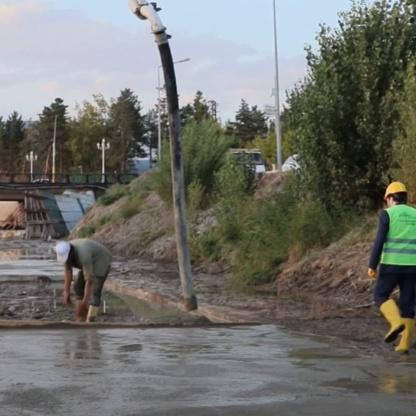

In [7]:
MAX_DISPLAY = 5
for p in image_paths[:MAX_DISPLAY]:
    print("Input image:", p.name)
    display(Image(filename=str(p), width=500))


### 8. Nạp checkpoint YOLOv8

Checkpoint `best.pt` là mô hình tốt nhất được lưu sau quá trình huấn luyện YOLOv8 trên bộ dữ liệu Safety Helmet. Mô hình dự đoán ba lớp: `Helmet`, `Head`, `Person`.


In [8]:
model = YOLO(str(checkpoint_path))

print("Model loaded from:", checkpoint_path)
class_names = model.names if isinstance(model.names, dict) else {i: name for i, name in enumerate(model.names)}
print("Class names:", class_names)


Model loaded from: /content/yolov8_helmet_inference/checkpoints/best_helmet_yolov8.pt
Class names: {0: 'head', 1: 'helmet', 2: 'person'}


### 9. Chạy inference trên ảnh kiểm thử

Có thể thay đổi `CONF_THRESHOLD` và `IOU_THRESHOLD` để điều chỉnh độ nhạy của mô hình. Ngưỡng confidence cao hơn sẽ giảm dự đoán sai nhưng có thể bỏ sót đối tượng nhỏ hoặc bị che khuất.


In [9]:
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.45

results = model.predict(
    source=str(IMAGE_DIR),
    conf=CONF_THRESHOLD,
    iou=IOU_THRESHOLD,
    save=True,
    save_txt=True,
    save_conf=True,
    project=str(OUTPUT_DIR),
    name="helmet_inference",
    exist_ok=True,
)

print("Inference done!")
print("Prediction folder:", OUTPUT_DIR / "helmet_inference")



image 1/1 /content/yolov8_helmet_inference/inputs/images/helmet_test_001.jpg: 640x640 2 helmets, 2 persons, 827.3ms
Speed: 26.5ms preprocess, 827.3ms inference, 43.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/yolov8_helmet_inference/outputs/helmet_inference
1 label saved to /content/yolov8_helmet_inference/outputs/helmet_inference/labels
Inference done!
Prediction folder: /content/yolov8_helmet_inference/outputs/helmet_inference


### 10. Hiển thị ảnh dự đoán

Các ảnh sau khi suy luận được lưu tại thư mục `outputs/helmet_inference`. Bounding Box hiển thị vị trí đối tượng, nhãn lớp và độ tin cậy của từng dự đoán.


Prediction image: helmet_test_001.jpg


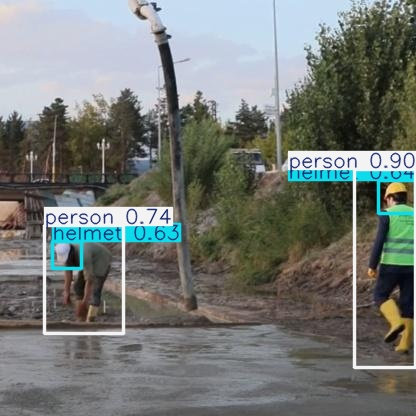

In [10]:
pred_dir = OUTPUT_DIR / "helmet_inference"
pred_images = collect_images(pred_dir)

if len(pred_images) == 0:
    raise FileNotFoundError(f"Không tìm thấy ảnh dự đoán trong {pred_dir}")

for p in pred_images[:MAX_DISPLAY]:
    print("Prediction image:", p.name)
    display(Image(filename=str(p), width=700))


### 11. Xuất bảng Bounding Box dự đoán

Bảng kết quả được lưu dưới dạng CSV, gồm tên ảnh, lớp dự đoán, confidence score và tọa độ Bounding Box theo định dạng `xyxy`.


In [11]:
rows = []

for r in results:
    image_name = Path(r.path).name
    boxes = r.boxes

    if boxes is None or len(boxes) == 0:
        rows.append({
            "image_name": image_name,
            "object_id": None,
            "class_id": None,
            "class_name": None,
            "confidence": None,
            "x1": None,
            "y1": None,
            "x2": None,
            "y2": None,
            "box_width": None,
            "box_height": None,
        })
        continue

    xyxy = boxes.xyxy.cpu().numpy()
    cls_ids = boxes.cls.cpu().numpy().astype(int)
    confs = boxes.conf.cpu().numpy()

    for object_id, (box, cls_id, conf) in enumerate(zip(xyxy, cls_ids, confs), start=1):
        x1, y1, x2, y2 = box
        rows.append({
            "image_name": image_name,
            "object_id": object_id,
            "class_id": int(cls_id),
            "class_name": class_names.get(int(cls_id), str(cls_id)),
            "confidence": round(float(conf), 4),
            "x1": round(float(x1), 2),
            "y1": round(float(y1), 2),
            "x2": round(float(x2), 2),
            "y2": round(float(y2), 2),
            "box_width": round(float(x2 - x1), 2),
            "box_height": round(float(y2 - y1), 2),
        })

boxes_df = pd.DataFrame(rows)
csv_path = OUTPUT_DIR / "prediction_boxes.csv"
boxes_df.to_csv(csv_path, index=False)

display(boxes_df)
print("Saved CSV:", csv_path)


,image_name,object_id,class_id,class_name,confidence,x1,y1,x2,y2,box_width,box_height
0,helmet_test_001.jpg,1,2,person,0.9043,354.76,169.39,415.65,367.55,60.89,198.16
1,helmet_test_001.jpg,2,2,person,0.7433,44.65,225.75,123.62,333.65,78.96,107.89
2,helmet_test_001.jpg,3,1,helmet,0.6350,378.65,180.05,415.43,213.69,36.78,33.63
3,helmet_test_001.jpg,4,1,helmet,0.6256,52.50,241.07,81.47,268.94,28.97,27.87


Saved CSV: /content/yolov8_helmet_inference/outputs/prediction_boxes.csv


### 12. Thống kê nhanh kết quả dự đoán

Bước này tổng hợp số lượng đối tượng được phát hiện theo từng lớp. Kết quả hỗ trợ nhận xét nhanh về khả năng nhận diện của mô hình trên ảnh kiểm thử.


In [12]:
valid_boxes = boxes_df.dropna(subset=["class_name"])

if valid_boxes.empty:
    print("Không có đối tượng nào được phát hiện.")
else:
    summary_df = (
        valid_boxes
        .groupby("class_name")
        .agg(num_objects=("object_id", "count"), mean_confidence=("confidence", "mean"))
        .reset_index()
    )
    summary_df["mean_confidence"] = summary_df["mean_confidence"].round(4)
    display(summary_df)


,class_name,num_objects,mean_confidence
0,helmet,2,0.6303
1,person,2,0.8238


### 13. Lưu kết quả để tải xuống

Notebook nén toàn bộ ảnh dự đoán, nhãn YOLO do mô hình sinh ra và file CSV vào một file `.zip`. Nếu chạy trên Google Colab, cell sẽ tự mở hộp thoại tải xuống.


In [13]:
zip_output_path = WORK_DIR / "yolov8_helmet_inference_outputs.zip"

if zip_output_path.exists():
    zip_output_path.unlink()

with zipfile.ZipFile(zip_output_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for file_path in pred_dir.rglob("*"):
        if file_path.is_file():
            zf.write(file_path, arcname=str(Path("helmet_inference") / file_path.relative_to(pred_dir)))

    if csv_path.exists():
        zf.write(csv_path, arcname="prediction_boxes.csv")

print("Saved zip file:", zip_output_path)

try:
    from google.colab import files
    files.download(str(zip_output_path))
except Exception:
    print("Không chạy trong Google Colab. Có thể tải thủ công tại:", zip_output_path)


Saved zip file: /content/yolov8_helmet_inference/yolov8_helmet_inference_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 14. Nhận xét và kết luận

Notebook đã hoàn thành pipeline inference YOLOv8 cho bài toán phát hiện mũ bảo hiểm. Quy trình đã tải checkpoint và ảnh/zip đầu vào bằng link, nạp mô hình, phát hiện các lớp `Helmet`, `Head`, `Person`, hiển thị Bounding Box và xuất kết quả ra file CSV/ZIP.

Việc tách riêng notebook inference giúp kiểm thử nhanh mô hình đã huấn luyện trên ảnh mới mà không cần chạy lại toàn bộ quá trình train/test. Cách tổ chức này cũng phù hợp khi nộp bài vì checkpoint, ảnh đầu vào và kết quả dự đoán đều có thể truy xuất trực tiếp bằng file hoặc link.
